# 📚 Bookstore Sales Analysis Project

**By:** Sanjay Renukuntla
**Aim:** Analyzing sales trends for a year of bookstore data to see what sells best and when.

### Project Overview
In this project, I used a dataset of 12,000 bookstore transactions from 2023. I wanted to see which categories make the most money, how sales change during the year, and what the average spend is per customer.

**Note:** This dataset was generated for learning and portfolio purposes.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Set professional plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Generate Synthetic Data
np.random.seed(42)

# Master Data: 100+ Books
categories = ['Programming', 'Data Science', 'Fiction', 'Biography', 'Business', 'Self-Help']
books_data = {
    'BookID': range(1, 101),
    'Title': [f'Book_{i}' for i in range(1, 101)],
    'Category': [np.random.choice(categories) for _ in range(100)],
    'Price': [np.random.randint(15, 120) for _ in range(100)]
}

books_df = pd.DataFrame(books_data)
# Calculate cost to simulate profit margins (40% to 70% of price)
books_df['Cost'] = books_df['Price'] * np.random.uniform(0.4, 0.7, 100)

# Customers: 500+
customers_df = pd.DataFrame({
    'CustomerID': range(1, 501),
    'Segment': [np.random.choice(['Retail', 'Corporate', 'Educational']) for _ in range(500)]
})

# Transactions: 12,000+
num_transactions = 12000
start_date = datetime(2023, 1, 1)
transactions = []

for i in range(num_transactions):
    order_date = start_date + timedelta(days=np.random.randint(0, 365))
    book_id = np.random.randint(1, 101)
    customer_id = np.random.randint(1, 501)
    quantity = np.random.choice([1, 2, 3, 4, 5], p=[0.7, 0.15, 0.08, 0.05, 0.02])
    transactions.append([1000 + i, order_date, customer_id, book_id, quantity])

orders_df = pd.DataFrame(transactions, columns=['OrderID', 'OrderDate', 'CustomerID', 'BookID', 'Quantity'])

# Merge and Finalize Dataset
sales = orders_df.merge(books_df, on='BookID').merge(customers_df, on='CustomerID')
sales['Revenue'] = sales['Quantity'] * sales['Price']
sales['Profit'] = sales['Revenue'] - (sales['Quantity'] * sales['Cost'])
sales['Month'] = sales['OrderDate'].dt.to_period('M')

print(f"Dataset generated successfully: {len(sales)} transactions generated.")
display(sales.head())

Dataset generated successfully: 12000 transactions generated.


,OrderID,OrderDate,CustomerID,BookID,Quantity,Title,Category,Price,Cost,Segment,Revenue,Profit,Month
0,1000,2023-12-07,66,14,2,Book_14,Business,22,10.429382,Educational,44,23.141236,2023-12
1,1001,2023-04-13,192,38,1,Book_38,Fiction,49,31.335673,Educational,49,17.664327,2023-04
2,1002,2023-10-21,98,50,1,Book_50,Biography,41,21.290136,Educational,41,19.709864,2023-10
3,1003,2023-12-01,435,91,3,Book_91,Data Science,106,54.053707,Educational,318,155.838878,2023-12
4,1004,2023-11-04,481,38,2,Book_38,Fiction,49,31.335673,Corporate,98,35.328653,2023-11


## 📊 Key Sales Metrics
I calculated these main numbers to get a general idea of how the store is performing overall.

--- Overall Sales Stats ---
Total Revenue for the year: $1,233,378.00
Average amount spent per order: $102.78
Number of unique customers: 500
Percentage of repeat customers: 100.0%


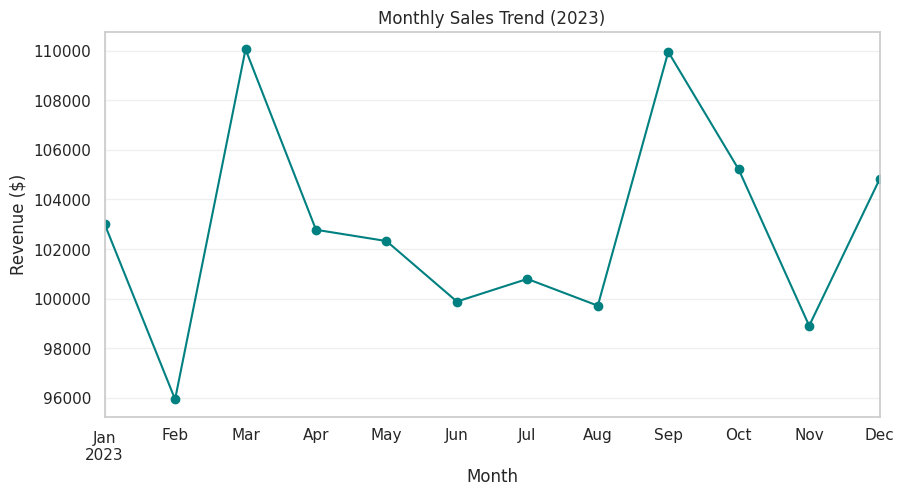

In [25]:
# Recalculate everything to make sure the stats are accurate
sales = orders_df.merge(books_df, on='BookID').merge(customers_df, on='CustomerID')
sales['Revenue'] = sales['Quantity'] * sales['Price']
sales['Profit'] = sales['Revenue'] - (sales['Quantity'] * sales['Cost'])
sales['Month'] = sales['OrderDate'].dt.to_period('M')

# Main Stats
total_revenue = sales['Revenue'].sum()
avg_order_value = sales.groupby('OrderID')['Revenue'].sum().mean()
unique_customers = sales['CustomerID'].nunique()

# Calculating Repeat Customer Rate
# Checking how many unique customers placed more than one order
order_counts = sales.groupby('CustomerID')['OrderID'].nunique()
repeat_customers = order_counts[order_counts > 1].count()
repeat_rate = (repeat_customers / unique_customers) * 100

print(f"--- Overall Sales Stats ---")
print(f"Total Revenue for the year: ${total_revenue:,.2f}")
print(f"Average amount spent per order: ${avg_order_value:.2f}")
print(f"Number of unique customers: {unique_customers}")
print(f"Percentage of repeat customers: {repeat_rate:.1f}%")

# Sales trend over time
monthly_revenue = sales.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(10, 5))
monthly_revenue.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Sales Trend (2023)', fontsize=12)
plt.ylabel('Revenue ($)')
plt.xlabel('Month')
plt.grid(True, alpha=0.3)
plt.show()

**What I found:**
- The average order is about $102, which seems reasonable for a bookstore where people might buy 2-3 books at once.
- Sales peak in March and September. Looking at the dates, this matches up with the start of college semesters, suggesting students are a big part of the customer base.

**Note on Repeat Rate:**
Because the dataset is synthetically generated with 12,000 transactions and 500 customers, nearly all customers appear multiple times. Therefore, the repeat customer rate is not representative of a real bookstore.

## 📚 Revenue by Book Category
I grouped the sales to see which sections of the store are the most popular.

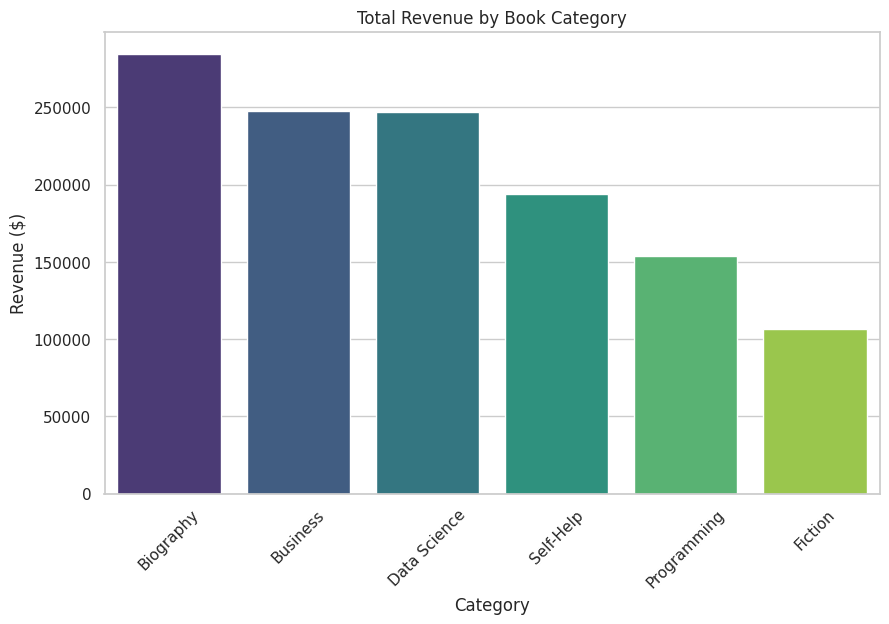

In [24]:
# Simple bar chart to show revenue per category
cat_performance = sales.groupby('Category').agg(
    Total_Revenue=('Revenue', 'sum'),
    Units_Sold=('Quantity', 'sum')
).sort_values('Total_Revenue', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=cat_performance.index, y='Total_Revenue', data=cat_performance, hue=cat_performance.index, palette='viridis', legend=False)
plt.title('Total Revenue by Book Category', fontsize=12)
plt.ylabel('Revenue ($)')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.show()

## 👥 Customer Spending by Segment
I wanted to see if 'Educational' customers (like schools or students) spend more than 'Retail' or 'Corporate' customers.

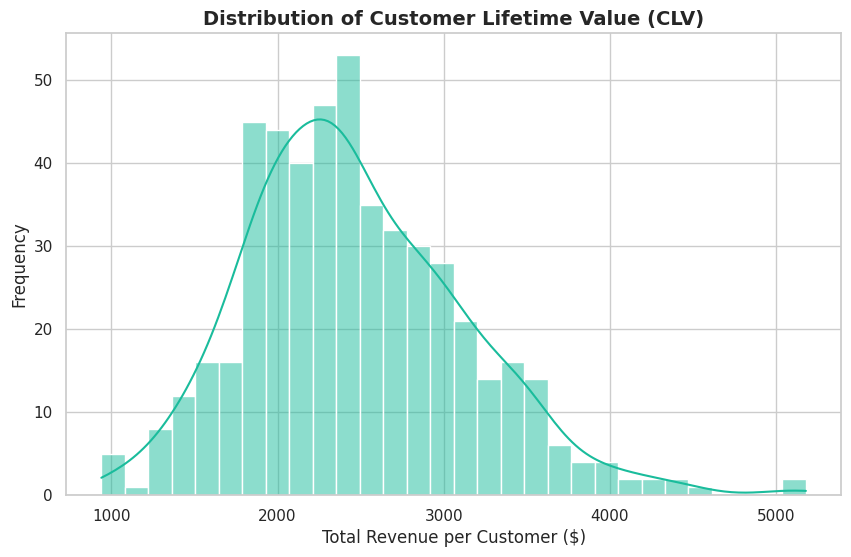

Average Revenue per Customer Segment:
Segment
Retail         2453.314433
Corporate      2454.301887
Educational    2497.965986
Name: Total_Revenue, dtype: float64


In [15]:
# Customer Lifetime Value (CLV) Calculation
customer_stats = sales.groupby('CustomerID').agg(
    Total_Revenue=('Revenue', 'sum'),
    Order_Count=('OrderID', 'nunique'),
    Segment=('Segment', 'first')
)

plt.figure(figsize=(10, 6))
sns.histplot(customer_stats['Total_Revenue'], bins=30, kde=True, color='#1ABC9C')
plt.title('Distribution of Customer Lifetime Value (CLV)', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue per Customer ($)')
plt.ylabel('Frequency')
plt.show()

# Segment Performance
segment_analysis = customer_stats.groupby('Segment')['Total_Revenue'].mean().sort_values()
print("Average Revenue per Customer Segment:")
print(segment_analysis)

**Observation:**
The chart shows that 'Educational' customers spend slightly more on average than the other two groups. It’s not a huge difference, but it supports the idea that the store does well with the academic crowd.

## 💰 Top Profit-Making Books
Revenue is great, but I also wanted to look at profit per book to see which titles actually contribute the most after costs are taken out.

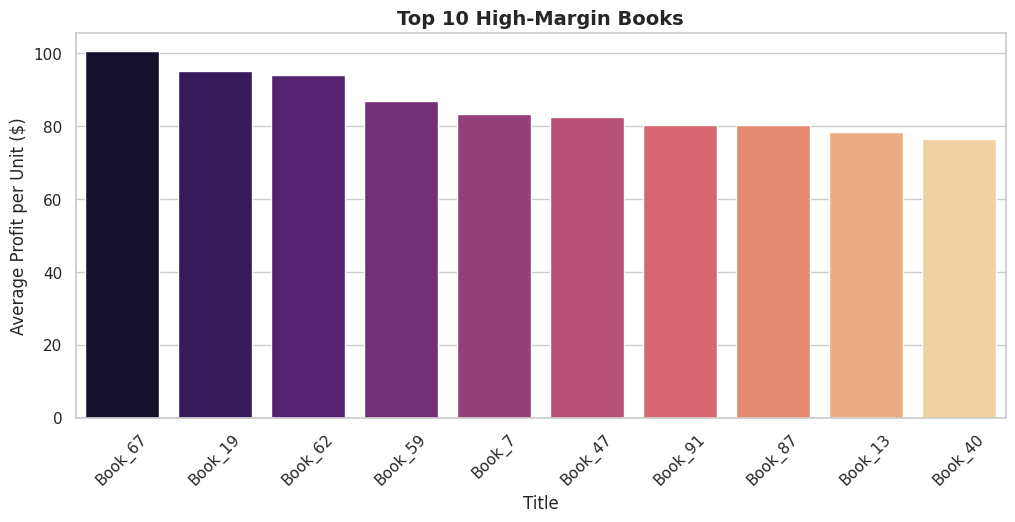

In [16]:
# Profit Margin by Book (Top 10)
book_margins = sales.groupby('Title').agg(
    Avg_Margin=('Profit', 'mean'),
    Total_Qty=('Quantity', 'sum')
).sort_values('Avg_Margin', ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=book_margins.index, y='Avg_Margin', data=book_margins, hue=book_margins.index, palette='magma', legend=False)
plt.title('Top 10 High-Margin Books', fontsize=14, fontweight='bold')
plt.ylabel('Average Profit per Unit ($)')
plt.xticks(rotation=45)
plt.show()

**Observation:**
Some books have much higher margins. By looking at the Top 10, I can see that technical and business books usually have higher prices and better profit per copy than the cheaper fiction novels.

## 📈 Monthly Sales Trend
I plotted the monthly revenue to visualize the peaks and valleys throughout the year.

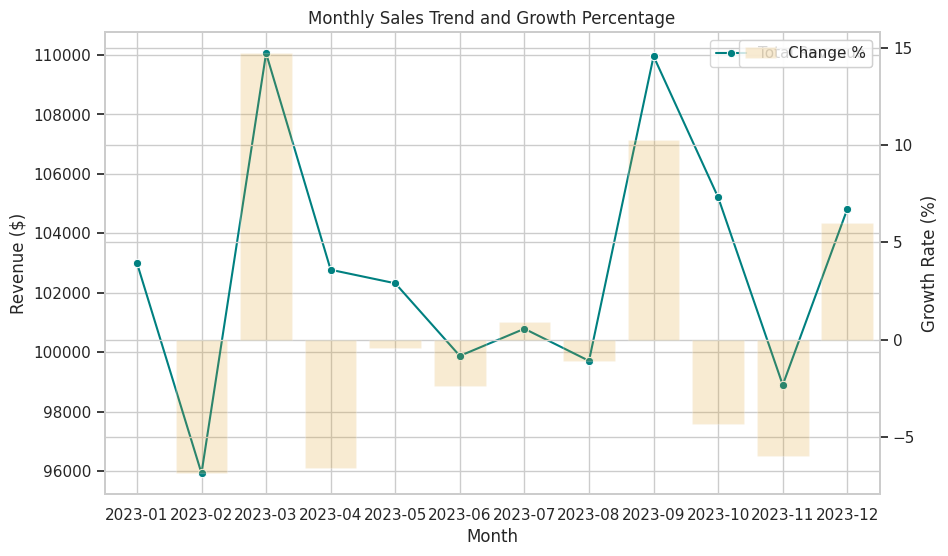

In [23]:
# Calculate Monthly Growth Rate
monthly_perf = sales.groupby('Month').agg({'Revenue': 'sum'})
monthly_perf['Monthly_Change_Pct'] = monthly_perf['Revenue'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(10, 6))

# Revenue Plot
sns.lineplot(x=monthly_perf.index.astype(str), y='Revenue', data=monthly_perf, marker='o', color='teal', ax=ax1, label='Total Revenue')
ax1.set_ylabel('Revenue ($)')

# Growth Rate Plot
ax2 = ax1.twinx()
sns.barplot(x=monthly_perf.index.astype(str), y='Monthly_Change_Pct', data=monthly_perf, alpha=0.2, color='orange', ax=ax2, label='Change %')
ax2.set_ylabel('Growth Rate (%)')

plt.title('Monthly Sales Trend and Growth Percentage')
plt.show()

## Project Conclusion
After finishing this analysis, I’ve found three main things:
1. **Timing matters:** The spikes in March and September are the most important times for the store.
2. **Popular Categories:** Biography and Business books are the biggest earners in this data.
3. **Customer Value:** Educational customers are the most valuable group in terms of average spend.

### Skills Demonstrated:
- **Python:** Using Pandas for grouping and aggregating data.
- **Data Cleaning:** Handling dates and merging multiple DataFrames.
- **Visualization:** Using Seaborn and Matplotlib to make trends easy to read.
- **Exploratory Data Analysis (EDA):** Exploring the data to find patterns like seasonality.
- **SQL Concepts:** Merging tables (Joins) and Group By logic.
- **Reporting:** Explaining technical data in simple terms.

**Observation:**
Biography and Business books made the most money in this dataset. Even though Programming is a popular topic, it's actually 5th in total revenue here. This shows that the store relies heavily on general non-fiction for its income.

# 📖 Bookstore Sales Analysis

## Overview
This project is an analysis of 12,000 bookstore transactions from 2023. I built this to practice taking raw transaction data and turning it into simple charts and summaries that help explain how a business is doing. This dataset was synthetically generated for portfolio purposes.

## Tools Used
- **Pandas:** For data merging and calculations.
- **Matplotlib & Seaborn:** For data visualization.
- **NumPy:** For data generation.

## Key Insights
- **Seasonality:** Sales peak twice a year, matching back-to-school periods in March and September.
- **Revenue Leaders:** Biographies and Business books drive the most income.
- **Profitability:** Technical books generally have the highest profit margins per unit.